In [2]:
from ultralytics import YOLO
import cv2

# Load model
# model = YOLO("../../runs/detect/train/weights/best.pt")
model = YOLO("/Users/rx0/Desktop/FoundationOfAIML/2/generational-bullshit/Models/test.pt")

# Load and resize image
image = cv2.imread("../../data/PNG/no_text/Ia_DS0801_sommaire.png")
# image = cv2.resize(image, (640, 640))

# Run inference
results = model(image)

# Show results
results[0].show()

# Save annotated result
results[0].save(filename="result.jpg")


0: 640x480 1 Column, 2 Dimensions, 8 Doors, 20 Walls, 1 Window, 109.4ms
Speed: 1.6ms preprocess, 109.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


'result.jpg'

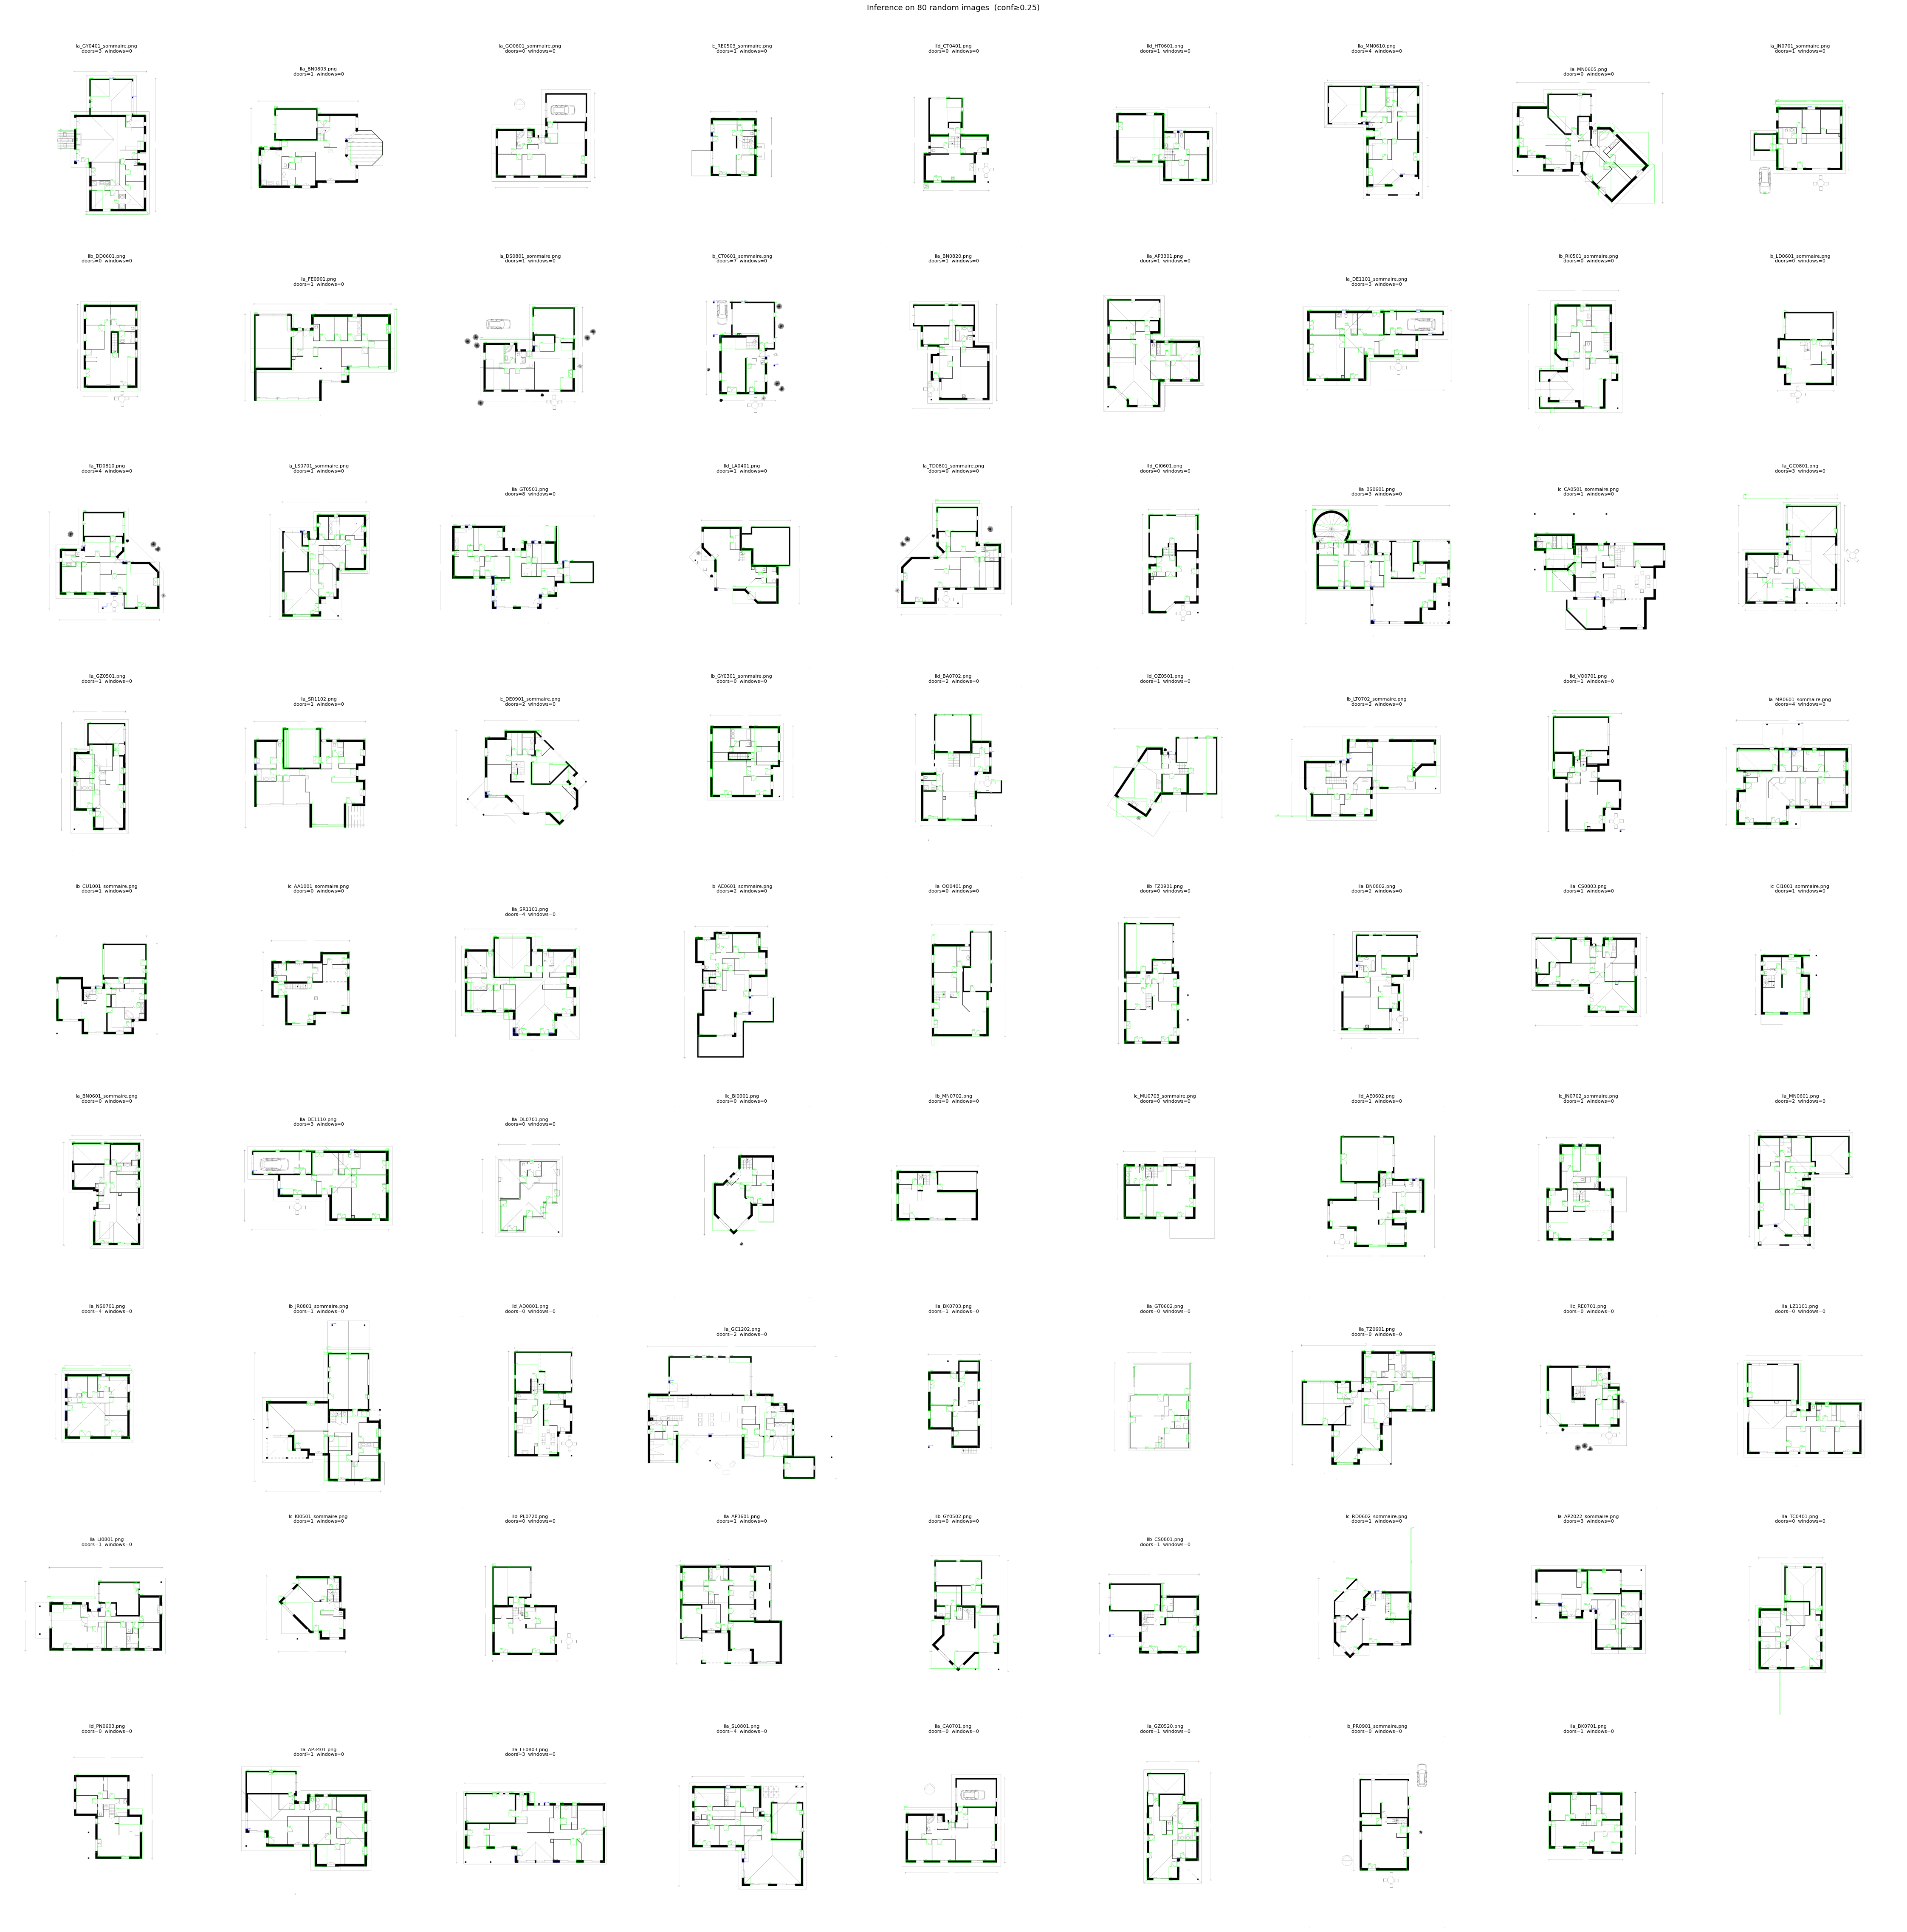

In [ ]:
import glob
import random
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

CLASS_NAMES = {0: "door", 1: "window"}
CLASS_COLORS = {0: (255, 80, 80), 1: (80, 180, 255)}

def plot_inference_grid(model_path, image_dir, n=9, conf=0.25, seed=42):
    random.seed(seed)
    model = YOLO(model_path)

    all_images = glob.glob(f"{image_dir}/*.png") + glob.glob(f"{image_dir}/*.jpg")
    sample = random.sample(all_images, min(n, len(all_images)))

    cols = math.ceil(math.sqrt(len(sample)))
    rows = math.ceil(len(sample) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    axes = np.array(axes).flatten()

    for ax, img_path in zip(axes, sample):
        img_bgr = cv2.imread(img_path)
        results = model(img_bgr, conf=conf, verbose=False)[0]

        annotated = img_bgr.copy()
        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            score = float(box.conf[0])
            color = CLASS_COLORS.get(cls, (0, 255, 0))
            label = f"{CLASS_NAMES.get(cls, cls)} {score:.2f}"
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            cv2.putText(annotated, label, (x1, max(y1 - 6, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

        n_doors = sum(1 for b in results.boxes if int(b.cls[0]) == 0)
        n_windows = sum(1 for b in results.boxes if int(b.cls[0]) == 1)
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{img_path.split('/')[-1]}\ndoors={n_doors}  windows={n_windows}", fontsize=8)
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.suptitle(f"Inference on {len(sample)} random images  (conf≥{conf})", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# ── configure here ──────────────────────────────────────────────────────────
plot_inference_grid(
    model_path="/Users/rx0/Desktop/FoundationOfAIML/2/generational-bullshit/Models/test.pt",
    image_dir="../../data/PNG/no_text",
    n=80,          # how many images to show
    conf=0.25,    # confidence threshold
    seed=42,      # change seed for a different random sample
)


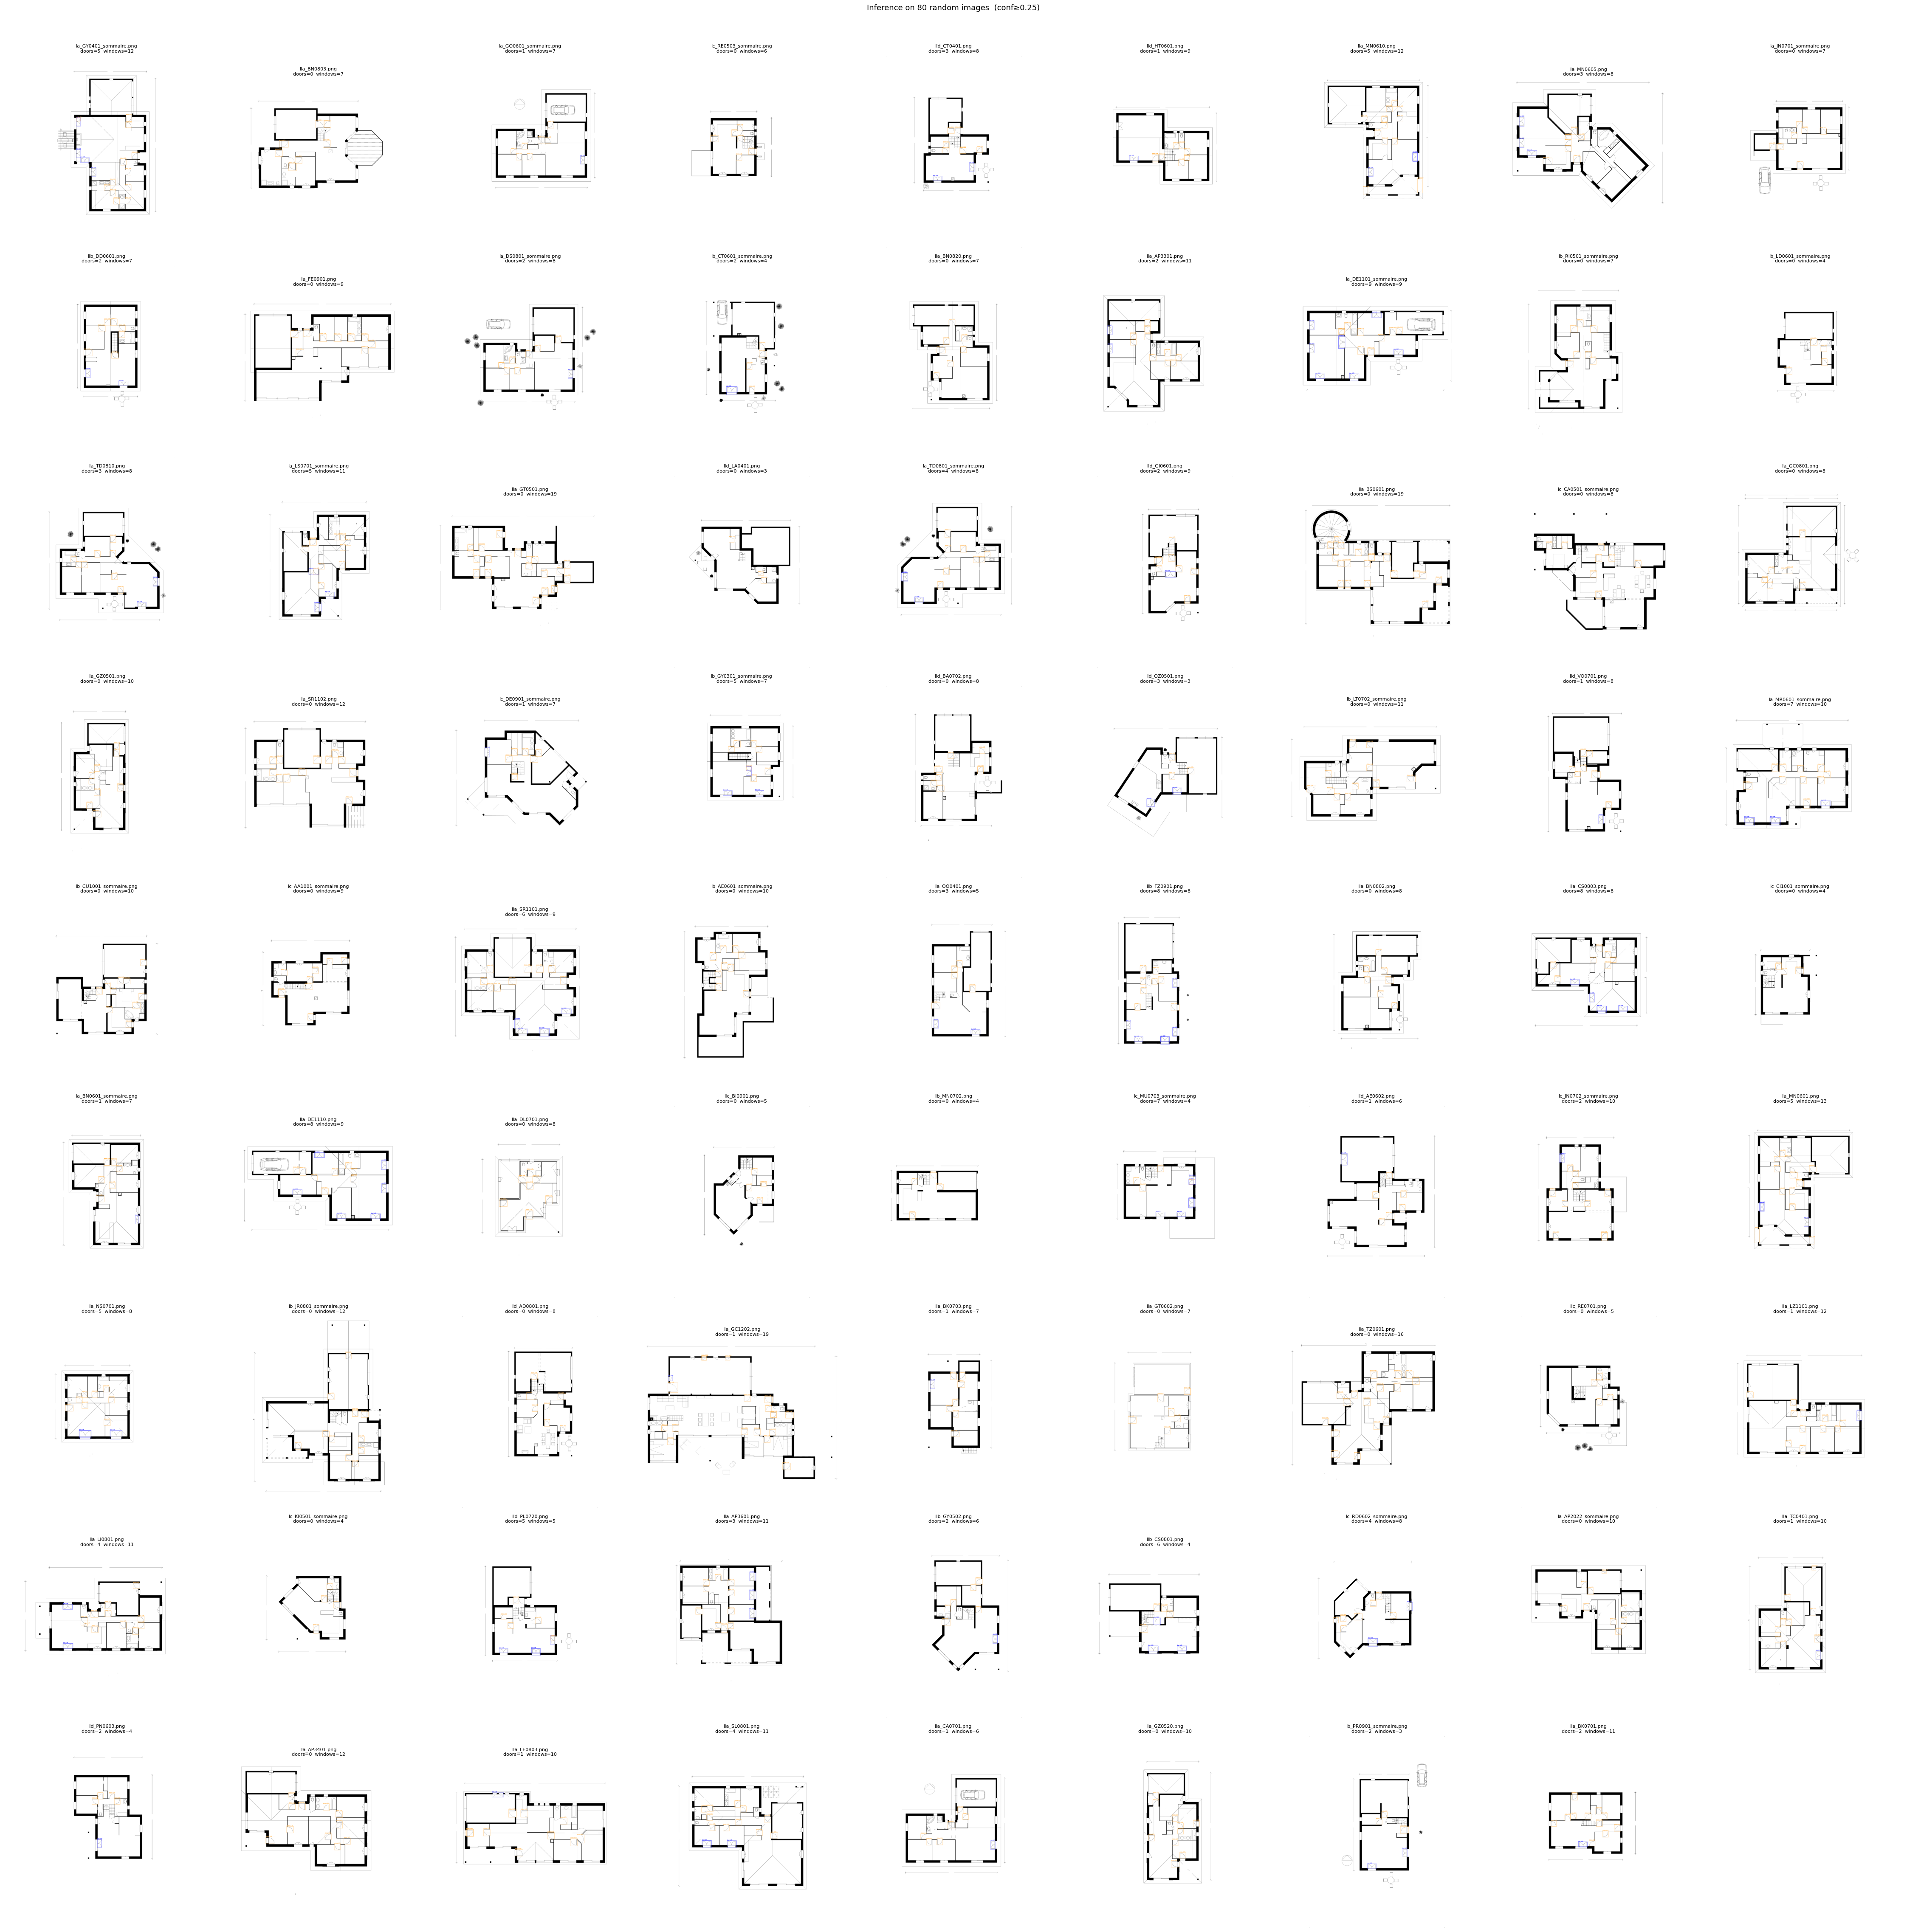

In [6]:
# ── configure here ──────────────────────────────────────────────────────────
plot_inference_grid(
    model_path="../../Models/best_v3.pt",
    image_dir="../../data/PNG/no_text",
    n=80,          # how many images to show
    conf=0.25,    # confidence threshold
    seed=42,      # change seed for a different random sample
)
